In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from NeuralNetwork import MLP

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


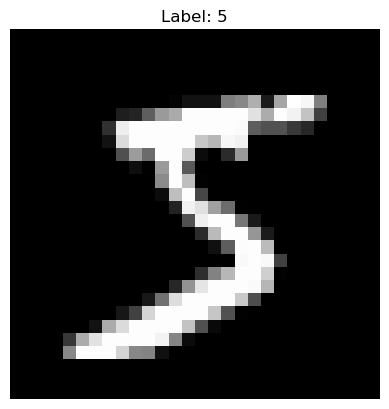

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Data Reading

path_train = "../data/mnist_100.csv"
path_test = "../data/mnist_10.csv"

df_train = pd.read_csv(path_train, header=None)
display(df_train)

data = df_train.iloc[0]
label = data[0]
img = data[1:].values.reshape(28, 28)

plt.imshow(img, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

df_test = pd.read_csv(path_test)
display(df_test)

In [28]:
# Data Processing

data_train = df_train.copy()
data_train = data_train.values

output_values_train = data_train[:, 0]
input_values_train = data_train[:, 1:]

input_values_train = input_values_train.astype(float)
input_values_train += 1
input_values_train /= 256

print("Train Values")
print(f"\nInput Values: {input_values_train}")
print(f"\nOutput Values: {output_values_train}")

data_test = df_test.copy()
data_test = data_test.values

output_values_test = data_test[:, 0]
input_values_test = data_test[:, 1:]

input_values_test = input_values_test.astype(float)
input_values_test += 1
input_values_test /= 256

print("\nTest Values")
print(f"\nInput Values: {input_values_test}")
print(f"\nOutput Values: {output_values_test}")

Train Values

Input Values: [[0.00390625 0.00390625 0.00390625 ... 0.00390625 0.00390625 0.00390625]
 [0.00390625 0.00390625 0.00390625 ... 0.00390625 0.00390625 0.00390625]
 [0.00390625 0.00390625 0.00390625 ... 0.00390625 0.00390625 0.00390625]
 ...
 [0.00390625 0.00390625 0.00390625 ... 0.00390625 0.00390625 0.00390625]
 [0.00390625 0.00390625 0.00390625 ... 0.00390625 0.00390625 0.00390625]
 [0.00390625 0.00390625 0.00390625 ... 0.00390625 0.00390625 0.00390625]]

Output Values: [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9 1 1 2 4 3 2 7 3 8 6 9 0 5 6
 0 7 6 1 8 7 9 3 9 8 5 9 3 3 0 7 4 9 8 0 9 4 1 4 4 6 0 4 5 6 1 0 0 1 7 1 6
 3 0 2 1 1 7 9 0 2 6 7 8 3 9 0 4 6 7 4 6 8 0 7 8 3 1]

Test Values

Input Values: [[0.00390625 0.00390625 0.00390625 ... 0.00390625 0.00390625 0.00390625]
 [0.00390625 0.00390625 0.00390625 ... 0.00390625 0.00390625 0.00390625]
 [0.00390625 0.00390625 0.00390625 ... 0.00390625 0.00390625 0.00390625]
 ...
 [0.00390625 0.00390625 0.00390625 ... 0.00390625 0.0039

In [ ]:
# Execution

# Architecture
neurons_per_layer = np.array([784, 100, 10]) # 3 layers with 3 neurons each
learning_rate = 0.3
activation_function = "sigmoid"

# Instantiation
model = MLP(neurons_per_layer, activation_function, learning_rate)

# Query
input = np.array([1.0, 0.5, -1.5], ndmin=2).T
target = np.array([1.0, 0.5, -1.5], ndmin=2).T
output = model.query(input)
output

([array([[ 0.00617071],
         [ 1.14741385],
         [-2.51082284]]),
  array([[0.07657401],
         [0.14947376],
         [0.12935433]])],
 [array([[0.50154267],
         [0.75903823],
         [0.07510293]]),
  array([[0.51913415],
         [0.53729902],
         [0.53229356]])])